In [1]:
!pip -q install --upgrade pip
!pip -q install torch tqdm numpy scikit-learn matplotlib

import os, numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

# (re)clone datasets (faster)
!rm -rf /content/datasets
!git clone --depth 1 https://github.com/CSTCloudOps/datasets.git /content/datasets

# ---- SMAP path (AllInOne) ----
allinone = "/content/datasets/MTS/SMAP/AllInOne"
required = ["train.npy", "test.npy", "train_label.npy", "test_label.npy"]
missing = [f for f in required if not os.path.exists(os.path.join(allinone, f))]
if missing:
    raise FileNotFoundError(f"Missing files in {allinone}: {missing}")

train = np.load(os.path.join(allinone, "train.npy")).astype(np.float32)        # (N,F)
test  = np.load(os.path.join(allinone, "test.npy")).astype(np.float32)         # (M,F)
train_label = np.load(os.path.join(allinone, "train_label.npy")).astype(int)   # (N,)
test_label  = np.load(os.path.join(allinone, "test_label.npy")).astype(int)    # (M,)

print("train:", train.shape, "test:", test.shape)
print("train_label:", train_label.shape, "test_label:", test_label.shape)
print("train anomaly ratio:", train_label.mean(), "test anomaly ratio:", test_label.mean())

F = train.shape[1]

Cloning into '/content/datasets'...
remote: Enumerating objects: 4493, done.
remote: Counting objects: 100% (4493/4493), done.
remote: Compressing objects: 100% (2529/2529), done.
remote: Total 4493 (delta 1975), reused 4475 (delta 1960), pack-reused 0 (from 0)
Receiving objects: 100% (4493/4493), 262.51 MiB | 17.16 MiB/s, done.
Resolving deltas: 100% (1975/1975), done.
Updating files: 100% (5564/5564), done.
train: (135183, 25) test: (427617, 25)
train_label: (135183,) test_label: (427617,)
train anomaly ratio: 0.0 test anomaly ratio: 0.12790885301566587


In [5]:
n_features = train.shape[1]
print("n_features:", n_features)

n_features: 25


In [2]:
class WindowDataset(Dataset):
    def __init__(self, x2d: np.ndarray, window: int):
        self.x = x2d
        self.w = window

    def __len__(self):
        return max(len(self.x) - self.w + 1, 0)

    def __getitem__(self, i):
        # returns (T,F)
        return torch.from_numpy(self.x[i:i+self.w])


WINDOW = 96
BATCH = 256

train_dataset = WindowDataset(train, WINDOW)
test_dataset  = WindowDataset(test, WINDOW)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH,
    shuffle=True,
    drop_last=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("train windows:", len(train_dataset))
print("test windows :", len(test_dataset))
print("train batches:", len(train_loader))
print("test batches :", len(test_loader))

train windows: 135088
test windows : 427522
train batches: 527
test batches : 1671


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TCNEncoder(nn.Module):
    def __init__(self, n_features: int, d_model: int = 64, emb_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(d_model, emb_dim)

    def forward(self, x):
        x = x.transpose(1, 2)      # (B,F,T)
        h = self.net(x).squeeze(-1)
        z = self.proj(h)
        z = F.normalize(z, p=2, dim=1)   # <<< important
        return z

In [6]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

encoder = TCNEncoder(n_features=n_features, d_model=64, emb_dim=64).to(device)
print("Encoder params:", sum(p.numel() for p in encoder.parameters()))

# ---- Compute DeepSVDD center c ----
encoder.eval()
with torch.no_grad():
    zs = []
    for X in train_loader:
        X = X.to(device, non_blocking=True)
        zs.append(encoder(X))
    Z = torch.cat(zs, dim=0)
    c = Z.mean(dim=0)

    # normalize center (important with normalized embeddings)
    c = F.normalize(c, p=2, dim=0)

c = c.detach()
print("Center shape:", tuple(c.shape))

Device: cpu
Encoder params: 21376


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Center shape: (64,)


In [7]:
import torch.optim as optim

EPOCHS = 10
LR = 1e-3

opt = optim.Adam(encoder.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

print("Training settings:")
print("Epochs:", EPOCHS)
print("Learning rate:", LR)
print("Weight decay:", 1e-4)

Training settings:
Epochs: 10
Learning rate: 0.001
Weight decay: 0.0001


DeepSVDD training (center c + minimize distance)

In [8]:
from tqdm import tqdm
import torch.optim as optim
import torch.nn.functional as F

# ---- training hyperparams ----
EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-4

opt = optim.Adam(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

print("Training settings:", {"epochs": EPOCHS, "lr": LR, "weight_decay": WEIGHT_DECAY})

# ---- (Re)compute center c ONCE (already normalized embeddings) ----
encoder.eval()
with torch.no_grad():
    zs = []
    for X in tqdm(train_loader, desc="Compute center c"):
        X = X.to(device, non_blocking=True)
        zs.append(encoder(X))
    Z = torch.cat(zs, dim=0)
    c = Z.mean(dim=0)
    c = F.normalize(c, p=2, dim=0)   # important with normalized embeddings

c = c.detach()
print("Center c shape:", tuple(c.shape))

# ---- Train DeepSVDD: minimize mean ||z - c||^2 ----
for ep in range(1, EPOCHS + 1):
    encoder.train()
    loss_sum = 0.0

    for X in tqdm(train_loader, desc=f"Train {ep}/{EPOCHS}"):
        X = X.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)

        z = encoder(X)  # already normalized
        dist = ((z - c) ** 2).sum(dim=1).mean()

        dist.backward()
        opt.step()

        loss_sum += float(dist.detach().cpu())

    scheduler.step()
    print(f"Epoch {ep}: loss={loss_sum/max(len(train_loader),1):.8f}")

torch.save({"encoder": encoder.state_dict(), "c": c.cpu().numpy()}, "deepsvdd_smap.pt")
print("Saved: deepsvdd_smap.pt")

Training settings: {'epochs': 10, 'lr': 0.001, 'weight_decay': 0.0001}


Compute center c:   0%|          | 0/527 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Compute center c: 100%|██████████| 527/527 [00:30<00:00, 17.02it/s]


Center c shape: (64,)


Train 1/10: 100%|██████████| 527/527 [00:53<00:00,  9.92it/s]


Epoch 1: loss=0.00013547


...

Epoch 8: loss=0.00000020


Train 9/10: 100%|██████████| 527/527 [12:25<00:00,  1.41s/it]


Epoch 9: loss=0.00000023


Train 10/10: 100%|██████████| 527/527 [11:28<00:00,  1.31s/it]

Epoch 10: loss=0.00000023
Saved: deepsvdd_smap.pt


collapse check

In [10]:
# --- Collapse check: embedding diversity on train windows ---
encoder.eval()
Z = []
with torch.no_grad():
    for X in train_loader:
        X = X.to(device, non_blocking=True)
        Z.append(encoder(X).cpu())

Z = torch.cat(Z, dim=0).numpy()

print("Z shape:", Z.shape)
print("Embedding std (mean over dims):", Z.std(axis=0).mean())
print("Embedding std (min/max over dims):", Z.std(axis=0).min(), Z.std(axis=0).max())

# norms should be ~1.0 because we L2-normalize embeddings
norms = np.linalg.norm(Z, axis=1)
print("Norm stats (min/mean/max):", norms.min(), norms.mean(), norms.max())

Z shape: (134912, 64)
Embedding std (mean over dims): 9.0302885e-05
Embedding std (min/max over dims): 7.945139e-08 0.00032121738
Norm stats (min/mean/max): 0.9999999 1.0 1.0000001


Inference: anomaly score per window + align labels

In [11]:
import numpy as np
import torch
from tqdm import tqdm

# Load checkpoint (reproducible inference)
ckpt = torch.load("deepsvdd_smap.pt", map_location=device, weights_only=False)
encoder.load_state_dict(ckpt["encoder"])

# center c
c = torch.tensor(ckpt["c"], device=device, dtype=torch.float32)

encoder.eval()
scores = []
with torch.no_grad():
    for X in tqdm(test_loader, desc="Test scoring"):
        X = X.to(device, non_blocking=True)
        z = encoder(X)
        s = ((z - c) ** 2).sum(dim=1)   # (B,)
        scores.append(s.cpu())

scores = torch.cat(scores, dim=0).numpy().astype(np.float64)
scores[np.isnan(scores)] = 1e9

print("scores len:", len(scores))
print("scores stats (min/median/max):",
      float(scores.min()), float(np.median(scores)), float(scores.max()))

# Align labels to window end: window i covers [i ... i+WINDOW-1]
start = WINDOW - 1
end = start + len(scores)

if end > len(test_label):
    raise ValueError(f"Label alignment exceeds test_label length: need {end}, have {len(test_label)}")

y_true = test_label[start:end].astype(int)

print("y_true len:", len(y_true), "aligned anomaly ratio:", y_true.mean())
assert len(y_true) == len(scores)

Test scoring: 100%|██████████| 1671/1671 [33:19<00:00,  1.20s/it]


scores len: 427522
scores stats (min/median/max): 1.669339440013573e-07 1.6698771787559963e-07 1.669990865593718e-07
y_true len: 427522 aligned anomaly ratio: 0.12793727574253488


Metrics (same style as KANAD notebook)

In [12]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import numpy as np

auc = roc_auc_score(y_true, scores)
ap  = average_precision_score(y_true, scores)

precision, recall, thresholds = precision_recall_curve(y_true, scores)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = int(np.argmax(f1))

best_f1 = float(f1[best_idx])
best_p  = float(precision[best_idx])
best_r  = float(recall[best_idx])
best_th = float(thresholds[best_idx]) if best_idx < len(thresholds) else float(thresholds[-1])

print("=== DeepSVDD (SMAP) ===")
print("ROC-AUC:", auc)
print("PR-AUC :", ap)
print("Best F1:", best_f1)
print("Best P/R:", best_p, best_r)
print("Best threshold:", best_th)

=== DeepSVDD (SMAP) ===
ROC-AUC: 0.51254059778883
PR-AUC : 0.15228406558142468
Best F1: 0.23654269052157645
Best P/R: 0.13625069483046137 0.8962812637121544
Best threshold: 1.6693779514298512e-07


Optional smoothing

In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import numpy as np

def moving_average(x, w=9):
    return np.convolve(x, np.ones(w)/w, mode="same")

scores_s = moving_average(scores, w=9)

auc_s = roc_auc_score(y_true, scores_s)
ap_s  = average_precision_score(y_true, scores_s)

p, r, th = precision_recall_curve(y_true, scores_s)
f1_s = 2 * (p * r) / (p + r + 1e-8)

best_idx = np.argmax(f1_s)

print("=== DeepSVDD (SMAP) with smoothing w=9 ===")
print("ROC-AUC:", auc_s)
print("PR-AUC :", ap_s)
print("Best F1:", f1_s[best_idx])
print("Best Precision:", p[best_idx])
print("Best Recall:", r[best_idx])

=== DeepSVDD (SMAP) with smoothing w=9 ===
ROC-AUC: 0.5117077689687441
PR-AUC : 0.14976409275159275
Best F1: 0.23663928562051068
Best Precision: 0.13630338549265128
Best Recall: 0.8967749012724879


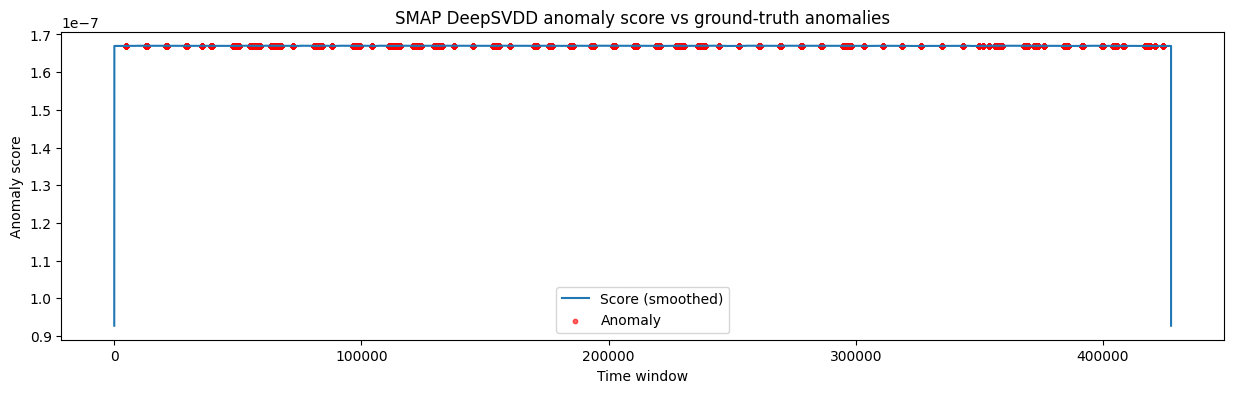

In [14]:
import matplotlib.pyplot as plt
import numpy as np

use_scores = scores_s if "scores_s" in globals() else scores

plt.figure(figsize=(15,4))
plt.plot(use_scores, label="Score (smoothed)" if "scores_s" in globals() else "Score")

anom_idx = np.where(y_true == 1)[0]
plt.scatter(anom_idx, use_scores[anom_idx], s=10, color="red", label="Anomaly", alpha=0.6)

plt.title("SMAP DeepSVDD anomaly score vs ground-truth anomalies")
plt.xlabel("Time window")
plt.ylabel("Anomaly score")
plt.legend()
plt.show()